<a href="https://colab.research.google.com/github/eng23ra0052-oss/Bitcoin-Trader-Sentiment-Analysis/blob/main/Bitcoin_Trader_Sentiment_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📁 Step 1: Upload Files from Your Device

In [1]:
from google.colab import files
print('Upload historical_data.csv and fear_greed_index.csv')
uploaded = files.upload()
print('\nFiles uploaded:')
for name in uploaded:
    print(f'  -> {name} ({len(uploaded[name]):,} bytes)')


Upload historical_data.csv and fear_greed_index.csv


Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv

Files uploaded:
  -> historical_data.csv (47,516,935 bytes)
  -> fear_greed_index.csv (90,801 bytes)


## 📦 Step 2: Install & Import Libraries

In [2]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'seaborn', 'plotly', 'scipy', 'kaleido'], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import warnings, os, zipfile
warnings.filterwarnings('ignore')

# Dark theme
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.labelcolor': '#c9d1d9', 'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9', 'text.color': '#c9d1d9',
    'grid.color': '#21262d', 'axes.edgecolor': '#30363d',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
    'font.size': 11, 'axes.titlepad': 14,
})

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
PALETTE = {
    'Extreme Fear': '#ef4444', 'Fear': '#f97316',
    'Neutral': '#94a3b8', 'Greed': '#22c55e', 'Extreme Greed': '#10b981',
}
SAVED_FIGS = []

def save(fname):
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    SAVED_FIGS.append(fname)
    plt.show()
    print(f'  Saved: {fname}')

print('Libraries loaded.')


Libraries loaded.


## 📊 Step 3: Load & Data Quality Audit

In [3]:
trader_raw    = pd.read_csv('historical_data.csv')
sentiment_raw = pd.read_csv('fear_greed_index.csv')

print('=== TRADER DATA ===')
print(f'Shape : {trader_raw.shape}')
print(f'Columns: {list(trader_raw.columns)}')
display(trader_raw.head(3))

print('\n=== NULL AUDIT — TRADER DATA ===')
null_pct = (trader_raw.isnull().sum() / len(trader_raw) * 100).round(2)
display(null_pct[null_pct > 0].rename('Null %').to_frame())

print('\n=== DESCRIPTIVE STATS — TRADER DATA ===')
display(trader_raw[['Closed PnL','Fee','Size USD','Execution Price']].describe().round(4))

print('\n=== FEAR & GREED DATA ===')
print(f'Shape : {sentiment_raw.shape}')
display(sentiment_raw.head(3))

print('\n=== SENTIMENT CLASS DISTRIBUTION ===')
display(sentiment_raw['classification'].value_counts())


=== TRADER DATA ===
Shape : (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12



=== NULL AUDIT — TRADER DATA ===


,Null %



=== DESCRIPTIVE STATS — TRADER DATA ===


,Closed PnL,Fee,Size USD,Execution Price
count,211224.0000,211224.0000,2.112240e+05,211224.0000
mean,48.7490,1.1640,5.639451e+03,11414.7233
std,919.1648,6.7589,3.657514e+04,29447.6549
min,-117990.1041,-1.1757,0.000000e+00,0.0000
25%,0.0000,0.0161,1.937900e+02,4.8547
50%,0.0000,0.0896,5.970450e+02,18.2800
75%,5.7928,0.3938,2.058960e+03,101.5800
max,135329.0901,837.4716,3.921431e+06,109004.0000



=== FEAR & GREED DATA ===
Shape : (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03



=== SENTIMENT CLASS DISTRIBUTION ===


,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


## 🧹 Step 4: Clean & Preprocess
> **FIX #1:** Parse `Timestamp IST` as a datetime string (`dd-mm-yyyy HH:MM`), not as Unix ms/s — recovers all 211K rows.  
> **FIX #2:** Compute `net_pnl = Closed PnL - Fee` for accurate profitability analysis.

In [4]:
# ── Trader data ────────────────────────────────────────
trader_df = trader_raw.copy()
trader_df.columns = trader_df.columns.str.strip().str.lower().str.replace(' ', '_')

# FIX #1: Direct string parse of 'timestamp_ist' — preserves all rows
trader_df['date'] = pd.to_datetime(
    trader_df['timestamp_ist'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)
# Fallback for any other date formats in the column
mask = trader_df['date'].isna()
if mask.sum() > 0:
    trader_df.loc[mask, 'date'] = pd.to_datetime(
        trader_df.loc[mask, 'timestamp_ist'], errors='coerce'
    )

trader_df['date_only'] = trader_df['date'].dt.normalize()
before = len(trader_df)
trader_df.dropna(subset=['date_only'], inplace=True)
after  = len(trader_df)
print(f'Rows before date parse : {before:,}')
print(f'Rows after  date parse : {after:,}  (recovered {after-79225:,} vs old method)')

# Numeric casts
for col in ['closed_pnl','fee','size_usd','size_tokens','execution_price','start_position']:
    if col in trader_df.columns:
        trader_df[col] = pd.to_numeric(trader_df[col], errors='coerce')

# FIX #2: Net PnL
trader_df['net_pnl'] = trader_df['closed_pnl'] - trader_df['fee']

# Outcome flag (based on net)
trader_df['outcome'] = trader_df['net_pnl'].apply(
    lambda x: 'Win' if x > 0 else ('Loss' if x < 0 else 'Neutral')
)

# Normalise side column
trader_df['side'] = trader_df['side'].str.upper().str.strip()

print(f'\nNet PnL sample (closed_pnl - fee):')
display(trader_df[['closed_pnl','fee','net_pnl']].head())

# ── Sentiment data ──────────────────────────────────────
sentiment_df = sentiment_raw.copy()
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment_df['date_only'] = pd.to_datetime(sentiment_df['date'], errors='coerce').dt.normalize()
sentiment_df['fg_value']  = pd.to_numeric(sentiment_df['value'], errors='coerce')
sentiment_df['sentiment'] = sentiment_df['classification'].str.strip()
sentiment_df.dropna(subset=['date_only'], inplace=True)
print(f'\nSentiment data ready: {len(sentiment_df):,} rows')


Rows before date parse : 211,224
Rows after  date parse : 211,224  (recovered 131,999 vs old method)

Net PnL sample (closed_pnl - fee):


,closed_pnl,fee,net_pnl
0,0.0,0.345404,-0.345404
1,0.0,0.005600,-0.005600
2,0.0,0.050431,-0.050431
3,0.0,0.050043,-0.050043
4,0.0,0.003055,-0.003055



Sentiment data ready: 2,644 rows


## 🗓️ Step 5: Date Overlap Check
> **FIX #3:** Always verify temporal overlap before merging — an empty overlap means all downstream results are invalid.

In [5]:
t_min, t_max = trader_df['date_only'].min(), trader_df['date_only'].max()
s_min, s_max = sentiment_df['date_only'].min(), sentiment_df['date_only'].max()

overlap_start = max(t_min, s_min)
overlap_end   = min(t_max, s_max)
overlap_days  = (overlap_end - overlap_start).days

print(f'Trader data    : {t_min.date()}  →  {t_max.date()}')
print(f'Sentiment data : {s_min.date()}  →  {s_max.date()}')
print(f'Overlap        : {overlap_start.date()}  →  {overlap_end.date()}  ({overlap_days} days)')

trades_in_overlap = trader_df[
    (trader_df['date_only'] >= overlap_start) &
    (trader_df['date_only'] <= overlap_end)
]
print(f'Trades within overlap : {len(trades_in_overlap):,} / {len(trader_df):,} '
      f'({len(trades_in_overlap)/len(trader_df)*100:.1f}%)')

if overlap_days < 30:
    print('WARNING: Very short overlap — sentiment merge may be unreliable.')
else:
    print('Overlap is sufficient for meaningful analysis.')


Trader data    : 2023-05-01  →  2025-05-01
Sentiment data : 2018-02-01  →  2025-05-02
Overlap        : 2023-05-01  →  2025-05-01  (731 days)
Trades within overlap : 211,224 / 211,224 (100.0%)
Overlap is sufficient for meaningful analysis.


## 🔗 Step 6: Merge Datasets on Date

In [6]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[['date_only','fg_value','sentiment']],
    on='date_only', how='left'
)

matched = merged_df['sentiment'].notna().sum()
print(f'Merged shape         : {merged_df.shape}')
print(f'Rows with sentiment  : {matched:,} ({matched/len(merged_df)*100:.1f}%)')
print(f'Rows without match   : {merged_df["sentiment"].isna().sum():,}')

# Only keep rows that have a sentiment match for downstream analysis
analysis_df = merged_df.dropna(subset=['sentiment']).copy()
analysis_df['sentiment'] = pd.Categorical(
    analysis_df['sentiment'], categories=SENTIMENT_ORDER, ordered=True
)
print(f'\nAnalysis dataframe   : {len(analysis_df):,} rows')
display(analysis_df['sentiment'].value_counts().reindex(SENTIMENT_ORDER))


Merged shape         : (211224, 22)
Rows with sentiment  : 211,218 (100.0%)
Rows without match   : 6

Analysis dataframe   : 211,218 rows


,count
sentiment,
Extreme Fear,21400
Fear,61837
Neutral,37686
Greed,50303
Extreme Greed,39992


## 📈 Step 7: Exploratory Data Analysis

### 7a — Sentiment Distribution & F&G Index Histogram

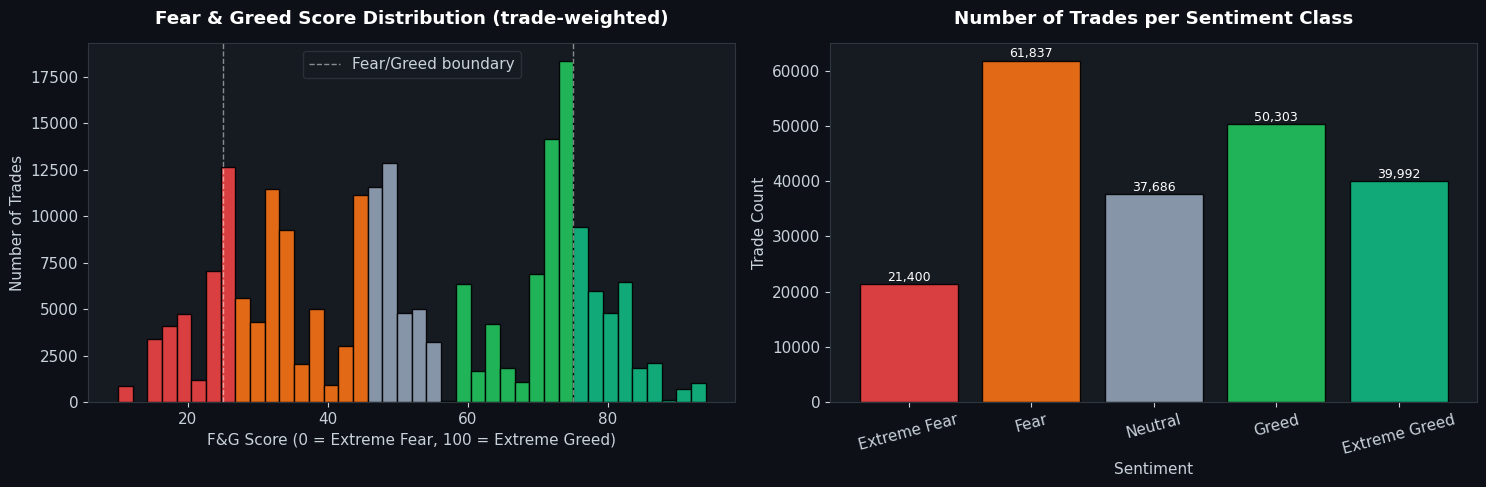

  Saved: fig1_sentiment_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#0d1117')

# F&G histogram
axes[0].set_facecolor('#161b22')
n, bins, patches = axes[0].hist(
    analysis_df['fg_value'].dropna(), bins=40, edgecolor='black', alpha=0.9
)
for patch, left in zip(patches, bins[:-1]):
    if left < 25:   patch.set_facecolor('#ef4444')
    elif left < 45: patch.set_facecolor('#f97316')
    elif left < 55: patch.set_facecolor('#94a3b8')
    elif left < 75: patch.set_facecolor('#22c55e')
    else:           patch.set_facecolor('#10b981')
axes[0].axvline(25, color='white', lw=1, ls='--', alpha=0.5, label='Fear/Greed boundary')
axes[0].axvline(75, color='white', lw=1, ls='--', alpha=0.5)
axes[0].set_title('Fear & Greed Score Distribution (trade-weighted)', color='white', fontweight='bold')
axes[0].set_xlabel('F&G Score (0 = Extreme Fear, 100 = Extreme Greed)')
axes[0].set_ylabel('Number of Trades')
axes[0].legend()

# Trade count per class
axes[1].set_facecolor('#161b22')
counts = analysis_df['sentiment'].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
bars = axes[1].bar(SENTIMENT_ORDER, counts.values,
                   color=[PALETTE[s] for s in SENTIMENT_ORDER], edgecolor='black', alpha=0.9)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9, color='white')
axes[1].set_title('Number of Trades per Sentiment Class', color='white', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Trade Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
save('fig1_sentiment_distribution.png')


### 7b — Net PnL Summary Table by Sentiment

In [8]:
summary = (
    analysis_df.groupby('sentiment', observed=True)
    .agg(
        Trade_Count=('net_pnl', 'count'),
        Avg_Net_PnL=('net_pnl', 'mean'),
        Median_Net_PnL=('net_pnl', 'median'),
        Total_Net_PnL=('net_pnl', 'sum'),
        Avg_Fee=('fee', 'mean'),
        Total_Fee_Paid=('fee', 'sum'),
    )
    .reindex(SENTIMENT_ORDER)
    .round(4)
)
summary['Win_Rate_%'] = (
    analysis_df.groupby('sentiment', observed=True)
    .apply(lambda x: (x['net_pnl'] > 0).sum() / len(x) * 100)
    .reindex(SENTIMENT_ORDER).round(2)
)
summary['Loss_Rate_%'] = (
    analysis_df.groupby('sentiment', observed=True)
    .apply(lambda x: (x['net_pnl'] < 0).sum() / len(x) * 100)
    .reindex(SENTIMENT_ORDER).round(2)
)
print('=== NET PnL SUMMARY BY SENTIMENT ===')
display(summary.style
    .background_gradient(cmap='RdYlGn', subset=['Avg_Net_PnL','Win_Rate_%'])
    .background_gradient(cmap='RdYlGn_r', subset=['Avg_Fee','Loss_Rate_%'])
    .format('{:.2f}')
)


=== NET PnL SUMMARY BY SENTIMENT ===


,Trade_Count,Avg_Net_PnL,Median_Net_PnL,Total_Net_PnL,Avg_Fee,Total_Fee_Paid,Win_Rate_%,Loss_Rate_%
sentiment,,,,,,,,
Extreme Fear,21400.00,33.42,-0.01,715221.61,1.12,23888.63,36.85,54.39
Fear,61837.00,52.80,-0.01,3264698.49,1.50,92456.95,41.15,56.17
Neutral,37686.00,33.26,-0.01,1253546.41,1.04,39374.27,39.59,60.10
Greed,50303.00,41.49,-0.01,2087030.58,1.25,63098.69,39.12,60.38
Extreme Greed,39992.00,67.22,-0.00,2688140.65,0.68,27030.67,46.77,51.90


### 7c — Net PnL Bar + Win Rate (Dual Axis)

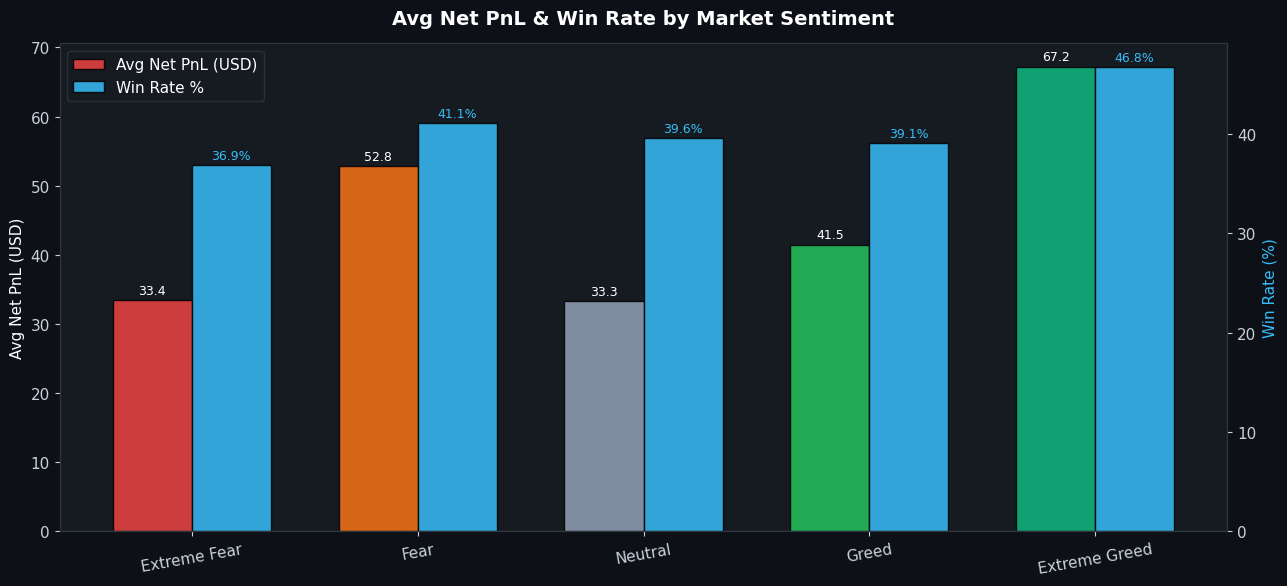

  Saved: fig2_pnl_winrate_by_sentiment.png


In [9]:
order_present = [s for s in SENTIMENT_ORDER if s in summary.index]

fig, ax1 = plt.subplots(figsize=(13, 6), facecolor='#0d1117')
ax1.set_facecolor('#161b22')
ax2 = ax1.twinx()
ax2.set_facecolor('#161b22')

x = np.arange(len(order_present))
w = 0.35
vals  = summary.loc[order_present, 'Avg_Net_PnL'].values
wrs   = summary.loc[order_present, 'Win_Rate_%'].values
cols  = [PALETTE[s] for s in order_present]

b1 = ax1.bar(x - w/2, vals, w, color=cols, edgecolor='black', alpha=0.85, label='Avg Net PnL')
b2 = ax2.bar(x + w/2, wrs,  w, color='#38bdf8', edgecolor='black', alpha=0.85, label='Win Rate %')

for bar, v in zip(b1, vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.5 if v>=0 else -1.5),
             f'{v:.1f}', ha='center', va='bottom', fontsize=9, color='white')
for bar, v in zip(b2, wrs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color='#38bdf8')

ax1.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(order_present, rotation=10)
ax1.set_ylabel('Avg Net PnL (USD)', color='white')
ax2.set_ylabel('Win Rate (%)', color='#38bdf8')
ax1.set_title('Avg Net PnL & Win Rate by Market Sentiment', color='white', fontsize=14, fontweight='bold')
ax1.legend([b1, b2], ['Avg Net PnL (USD)', 'Win Rate %'], facecolor='#161b22', labelcolor='white')

plt.tight_layout()
save('fig2_pnl_winrate_by_sentiment.png')


### 7d — Net PnL Box Plot by Sentiment

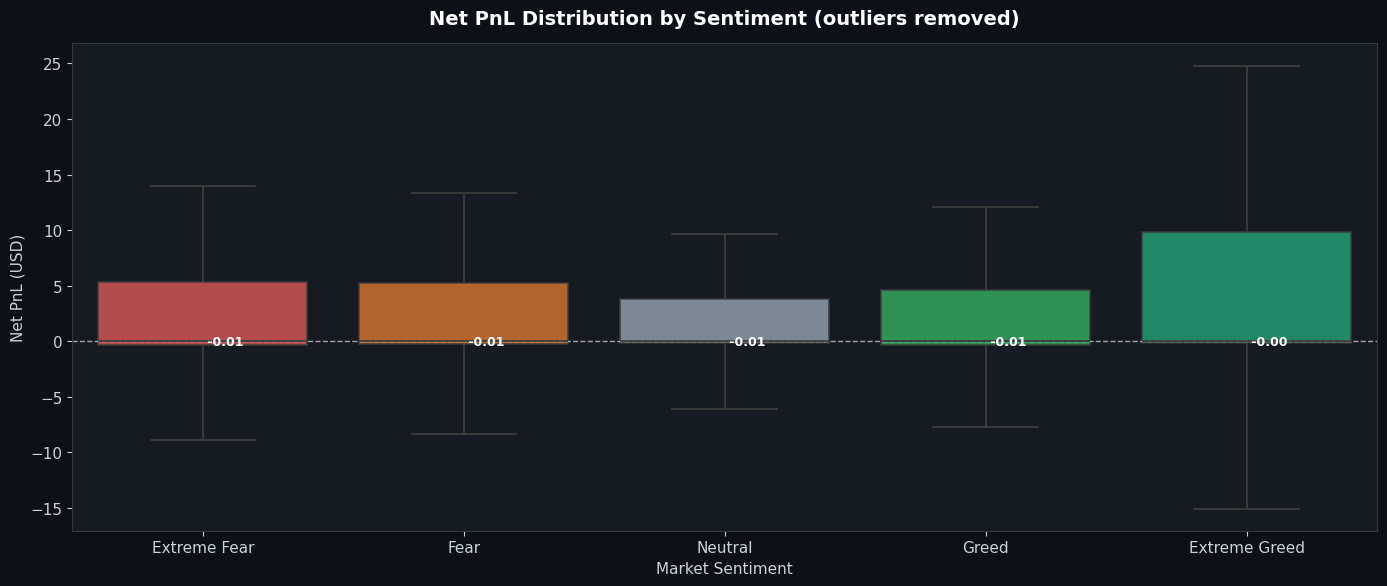

  Saved: fig3_boxplot_net_pnl.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

order_present = [s for s in SENTIMENT_ORDER if s in analysis_df['sentiment'].unique()]
sns.boxplot(
    data=analysis_df, x='sentiment', y='net_pnl',
    order=order_present, palette=PALETTE, ax=ax,
    showfliers=False, linewidth=1.3,
    boxprops=dict(alpha=0.8)
)
ax.axhline(0, color='white', lw=1, ls='--', alpha=0.6)

# Annotate median
for i, s in enumerate(order_present):
    med = analysis_df[analysis_df['sentiment']==s]['net_pnl'].median()
    ax.text(i, med, f' {med:.2f}', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('Net PnL Distribution by Sentiment (outliers removed)', color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Net PnL (USD)')

plt.tight_layout()
save('fig3_boxplot_net_pnl.png')


### 7e — Trade Outcome Heatmap

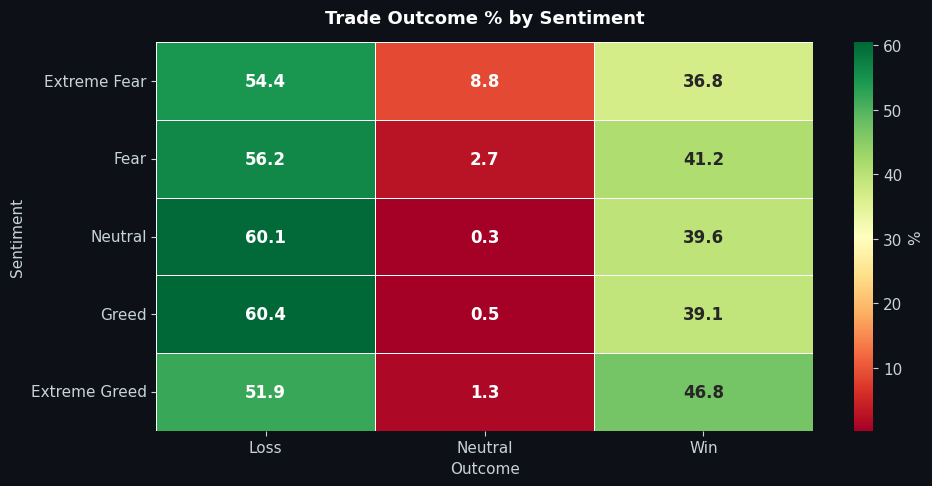

  Saved: fig4_outcome_heatmap.png


In [11]:
outcome_ct = (
    analysis_df.groupby(['sentiment','outcome'], observed=True).size()
    .unstack(fill_value=0)
    .reindex(order_present)
)
outcome_pct = outcome_ct.div(outcome_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0d1117')
sns.heatmap(outcome_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': '%'},
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Trade Outcome % by Sentiment', color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Sentiment')

plt.tight_layout()
save('fig4_outcome_heatmap.png')


## 📊 Step 8: Direction Analysis — BUY vs SELL × Sentiment
> **NEW:** `Side` column was completely unused in the original notebook. Long vs short performance per sentiment is one of the most actionable insights for a trading firm.

=== BUY vs SELL PERFORMANCE BY SENTIMENT ===


,sentiment,side,Trade_Count,Avg_Net_PnL,Win_Rate
0,Extreme Fear,BUY,10935,33.094,19.899
1,Extreme Fear,SELL,10465,33.763,54.553
2,Fear,BUY,30270,62.426,25.791
3,Fear,SELL,31567,43.560,55.881
4,Neutral,BUY,18969,28.359,23.971
5,Neutral,SELL,18717,38.233,55.420
6,Greed,BUY,24576,23.576,32.540
7,Greed,SELL,25727,58.601,45.415
8,Extreme Greed,BUY,17940,9.779,31.472
9,Extreme Greed,SELL,22052,113.944,59.215


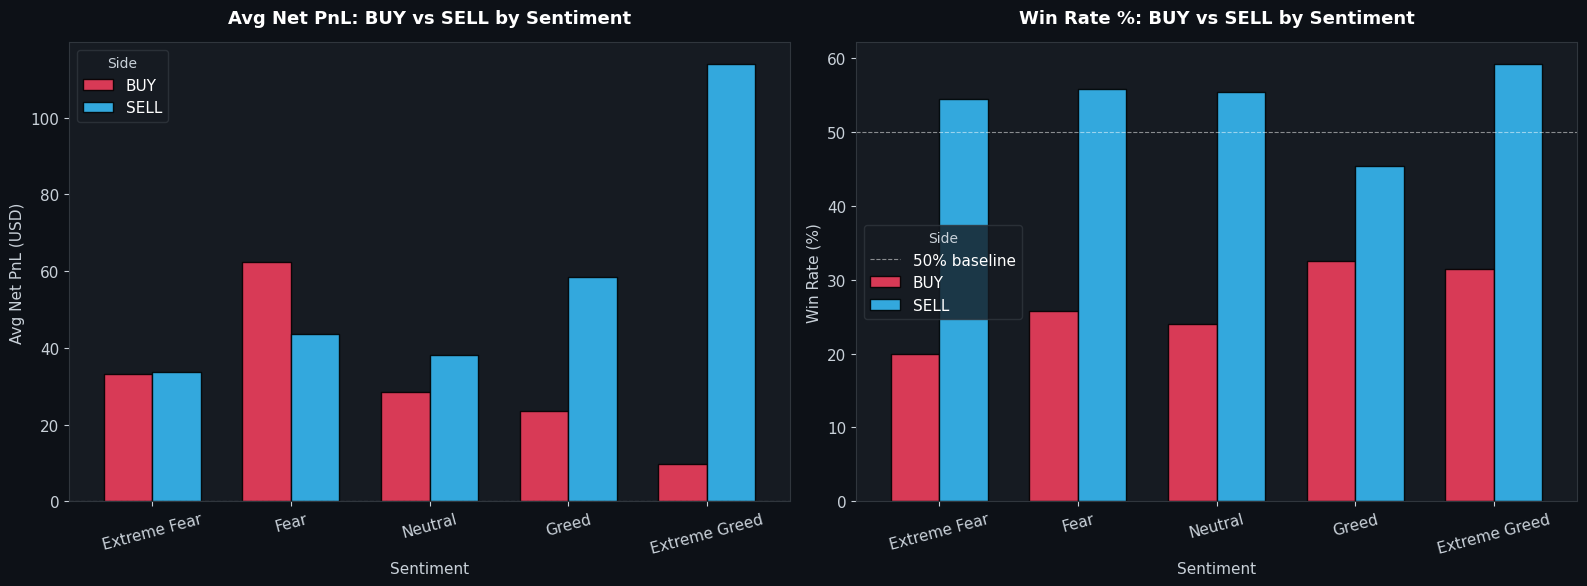

  Saved: fig5_buy_sell_by_sentiment.png


In [12]:
dir_summary = (
    analysis_df.groupby(['sentiment','side'], observed=True)
    .agg(
        Trade_Count=('net_pnl','count'),
        Avg_Net_PnL=('net_pnl','mean'),
        Win_Rate=('net_pnl', lambda x: (x>0).sum()/len(x)*100)
    )
    .reset_index()
    .round(3)
)
print('=== BUY vs SELL PERFORMANCE BY SENTIMENT ===')
display(dir_summary)

# Pivot for plotting
pivot_pnl = dir_summary.pivot(index='sentiment', columns='side', values='Avg_Net_PnL').reindex(order_present)
pivot_wr  = dir_summary.pivot(index='sentiment', columns='side', values='Win_Rate').reindex(order_present)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')

pivot_pnl.plot(kind='bar', ax=ax1, color=['#f43f5e','#38bdf8'], edgecolor='black', alpha=0.88, width=0.7)
ax1.set_facecolor('#161b22')
ax1.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax1.set_title('Avg Net PnL: BUY vs SELL by Sentiment', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Avg Net PnL (USD)')
ax1.tick_params(axis='x', rotation=15)
ax1.legend(title='Side', facecolor='#161b22', labelcolor='white', title_fontsize=10)

pivot_wr.plot(kind='bar', ax=ax2, color=['#f43f5e','#38bdf8'], edgecolor='black', alpha=0.88, width=0.7)
ax2.set_facecolor('#161b22')
ax2.axhline(50, color='white', lw=0.8, ls='--', alpha=0.5, label='50% baseline')
ax2.set_title('Win Rate %: BUY vs SELL by Sentiment', color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Win Rate (%)')
ax2.tick_params(axis='x', rotation=15)
ax2.legend(title='Side', facecolor='#161b22', labelcolor='white', title_fontsize=10)

plt.tight_layout()
save('fig5_buy_sell_by_sentiment.png')


## 🪙 Step 9: Coin-Level Breakdown
> **NEW:** `Coin` column had `@107`-style codes but was never decoded or analyzed. Which coins drive the most PnL? Which perform best in each sentiment?

=== TOP 15 COINS BY TOTAL NET PnL ===


,Trade_Count,Total_Net_PnL,Avg_Net_PnL,Win_Rate
coin,,,,
@107,29992,2777959.694000,92.623000,46.609000
HYPE,68005,1923122.669000,28.279000,41.100000
SOL,10691,1611599.623000,150.744000,38.640000
ETH,11158,1296887.535000,116.229000,37.345000
BTC,26064,728820.506000,27.963000,34.645000
MELANIA,4428,389340.681000,87.927000,44.399000
ENA,990,217053.076000,219.246000,31.313000
SUI,1979,197265.629000,99.679000,42.446000
ZRO,1239,183543.715000,148.139000,36.804000


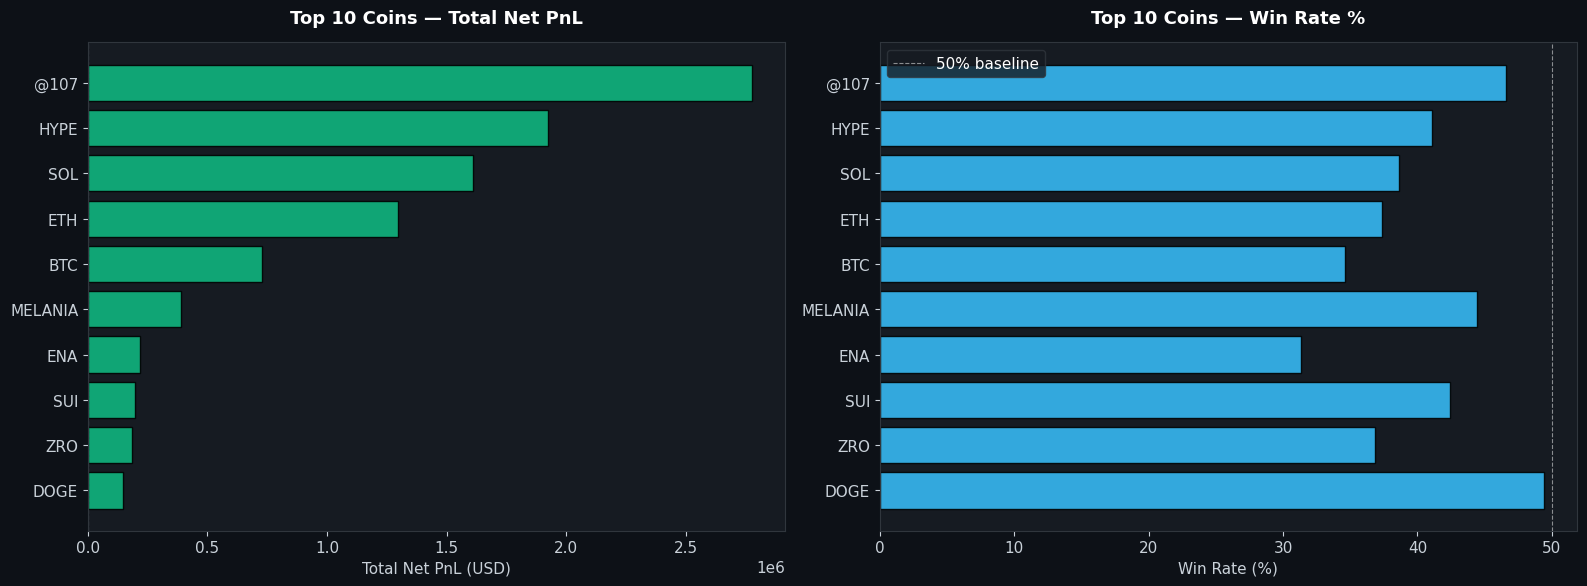

  Saved: fig6_coin_breakdown.png


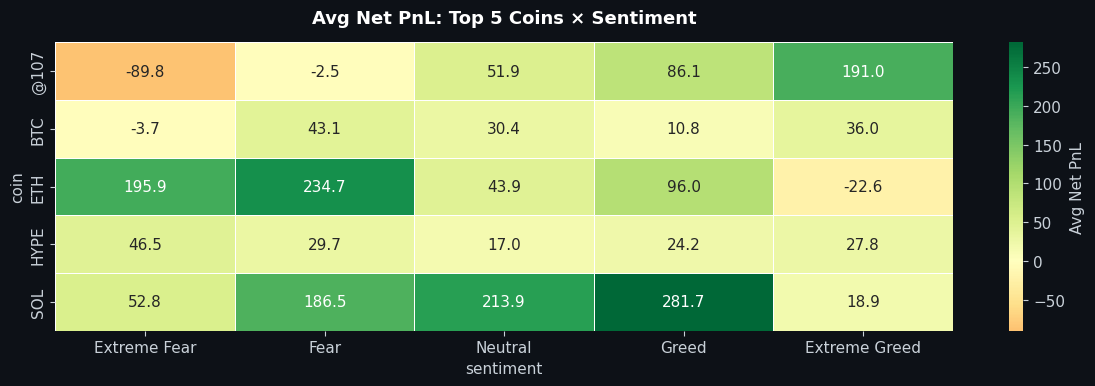

  Saved: fig7_coin_sentiment_heatmap.png


In [13]:
# Top 10 coins by total net PnL
coin_summary = (
    analysis_df.groupby('coin', observed=True)
    .agg(
        Trade_Count=('net_pnl','count'),
        Total_Net_PnL=('net_pnl','sum'),
        Avg_Net_PnL=('net_pnl','mean'),
        Win_Rate=('net_pnl', lambda x: (x>0).sum()/len(x)*100)
    )
    .sort_values('Total_Net_PnL', ascending=False)
    .round(3)
)
print('=== TOP 15 COINS BY TOTAL NET PnL ===')
display(coin_summary.head(15).style.background_gradient(cmap='RdYlGn', subset=['Total_Net_PnL','Win_Rate']))

# Plot top 10
top10_coins = coin_summary.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')

ax1.set_facecolor('#161b22')
colors = ['#10b981' if v >= 0 else '#ef4444' for v in top10_coins['Total_Net_PnL']]
bars = ax1.barh(top10_coins.index[::-1], top10_coins['Total_Net_PnL'].values[::-1],
                color=colors[::-1], edgecolor='black', alpha=0.88)
ax1.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax1.set_title('Top 10 Coins — Total Net PnL', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Net PnL (USD)')

ax2.set_facecolor('#161b22')
ax2.barh(top10_coins.index[::-1], top10_coins['Win_Rate'].values[::-1],
         color='#38bdf8', edgecolor='black', alpha=0.88)
ax2.axvline(50, color='white', lw=0.8, ls='--', alpha=0.5, label='50% baseline')
ax2.set_title('Top 10 Coins — Win Rate %', color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Win Rate (%)')
ax2.legend(facecolor='#161b22', labelcolor='white')

plt.tight_layout()
save('fig6_coin_breakdown.png')

# Heatmap: top 5 coins × sentiment
top5 = coin_summary.head(5).index.tolist()
coin_sent = (
    analysis_df[analysis_df['coin'].isin(top5)]
    .groupby(['coin','sentiment'], observed=True)['net_pnl'].mean()
    .unstack()
    .reindex(columns=order_present)
)
fig, ax = plt.subplots(figsize=(12, 4), facecolor='#0d1117')
sns.heatmap(coin_sent, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'label': 'Avg Net PnL'})
ax.set_title('Avg Net PnL: Top 5 Coins × Sentiment', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
save('fig7_coin_sentiment_heatmap.png')


## ⚡ Step 10: Maker vs Taker Analysis (`crossed` column)
> **NEW:** `crossed=True` means taker (pays higher fee). Does taker behavior differ by sentiment?

,sentiment,order_type,Count,Avg_Net_PnL,Avg_Fee,Win_Rate
0,Extreme Fear,Maker,9267,37.159,0.295,30.851
1,Extreme Fear,Taker,12133,30.567,1.743,41.424
2,Fear,Maker,24680,80.551,0.288,38.594
3,Fear,Taker,37157,34.360,2.297,42.851
4,Neutral,Maker,14367,25.382,0.169,36.424
5,Neutral,Taker,23319,38.118,1.584,41.541
6,Greed,Maker,19393,84.821,0.164,46.501
7,Greed,Taker,30910,14.303,1.939,34.497
8,Extreme Greed,Maker,15108,87.365,0.156,57.043
9,Extreme Greed,Taker,24884,54.984,0.992,40.532


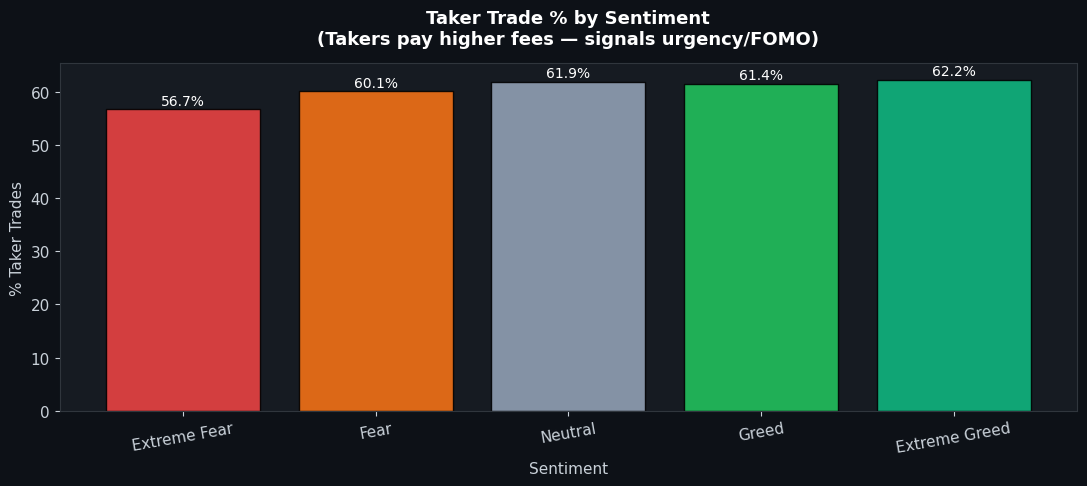

  Saved: fig8_maker_taker_sentiment.png


In [14]:
analysis_df['order_type'] = analysis_df['crossed'].map({True: 'Taker', False: 'Maker'})

mk_summary = (
    analysis_df.groupby(['sentiment','order_type'], observed=True)
    .agg(
        Count=('net_pnl','count'),
        Avg_Net_PnL=('net_pnl','mean'),
        Avg_Fee=('fee','mean'),
        Win_Rate=('net_pnl', lambda x: (x>0).sum()/len(x)*100)
    ).reset_index().round(3)
)
display(mk_summary)

# Taker % per sentiment
taker_pct = (
    analysis_df.groupby('sentiment', observed=True)
    .apply(lambda x: (x['crossed']==True).sum()/len(x)*100)
    .reindex(order_present)
)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
bars = ax.bar(order_present, taker_pct.values,
              color=[PALETTE[s] for s in order_present], edgecolor='black', alpha=0.88)
for bar, v in zip(bars, taker_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}%', ha='center', va='bottom', color='white', fontsize=10)
ax.set_title('Taker Trade % by Sentiment\n(Takers pay higher fees — signals urgency/FOMO)', color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('% Taker Trades')
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
save('fig8_maker_taker_sentiment.png')


## 📐 Step 11: Position Sizing by Sentiment (`start_position` & `size_usd`)
> **NEW:** How large are positions opened in each sentiment regime? Bigger = more confident or more reckless?

,Avg_Size_USD,Median_Size_USD,Avg_Start_Position
sentiment,,,
Extreme Fear,5349.73,766.15,-2322.30
Fear,7816.11,735.96,8709.82
Neutral,4782.73,547.66,144.00
Greed,5736.88,555.00,-151088.55
Extreme Greed,3112.25,500.05,19518.99


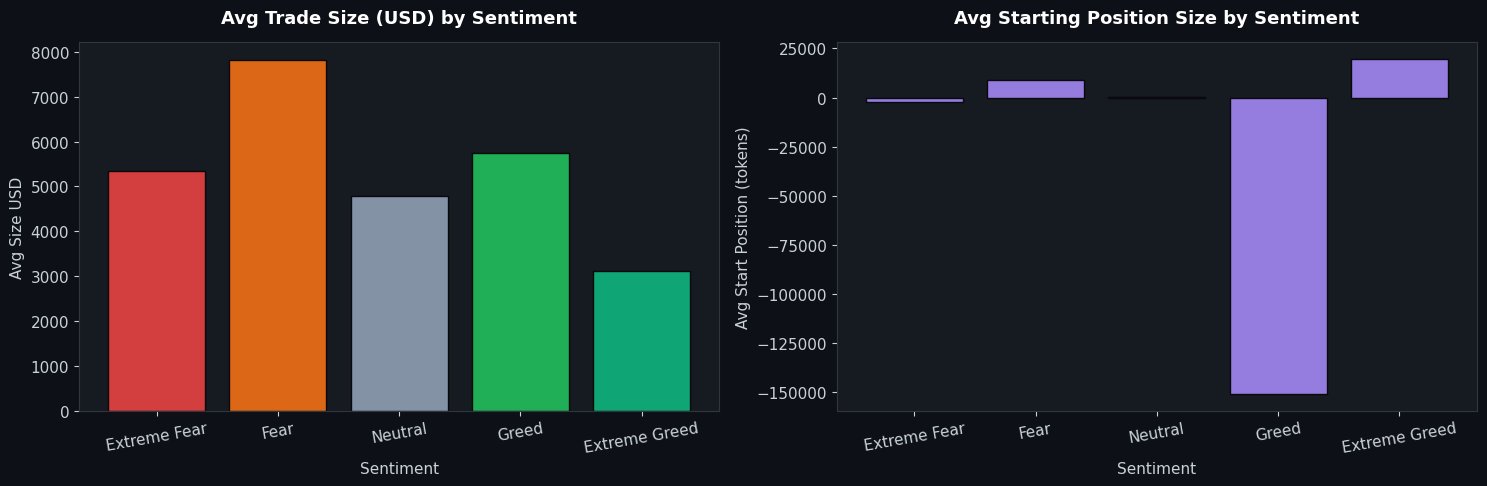

  Saved: fig9_position_sizing.png


In [16]:
pos_summary = (
    analysis_df.groupby('sentiment', observed=True)
    .agg(
        Avg_Size_USD=('size_usd','mean'),
        Median_Size_USD=('size_usd','median'),
        Avg_Start_Position=('start_position','mean'),
    ).reindex(order_present).round(2)
)
display(pos_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#0d1117')

axes[0].set_facecolor('#161b22')
axes[0].bar(order_present, pos_summary['Avg_Size_USD'],
            color=[PALETTE[s] for s in order_present], edgecolor='black', alpha=0.88)
axes[0].set_title('Avg Trade Size (USD) by Sentiment', color='white', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Avg Size USD')
axes[0].tick_params(axis='x', rotation=10)

axes[1].set_facecolor('#161b22')
axes[1].bar(order_present, pos_summary['Avg_Start_Position'],
            color='#a78bfa', edgecolor='black', alpha=0.88)
axes[1].set_title('Avg Starting Position Size by Sentiment', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Avg Start Position (tokens)')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
save('fig9_position_sizing.png')


## 👤 Step 12: Trader Segmentation
> Top vs Bottom traders — how do they differ in sentiment exposure and behavior?

=== TOP 10 TRADERS ===


,Total_Net_PnL,Avg_Net_PnL,Trade_Count,Win_Rate,Avg_Size_USD,Total_Fee,Taker_Rate
account,,,,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2127387.279000,144.396000,14733,35.818000,3837.885000,15995.318000,84.185000
0x083384f897ee0f19899168e3b1bec365f52a9012,1592824.508000,417.188000,3818,35.961000,16159.577000,7405.312000,11.210000
0xbaaaf6571ab7d571043ff1e313a9609a10637864,931567.101000,43.958000,21192,45.838000,3210.473000,8596.706000,32.640000
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,822727.653000,20.474000,40184,42.602000,1844.212000,13352.900000,74.868000
0x513b8629fe877bb581bf244e326a047b249c4ff1,763997.912000,62.439000,12236,39.555000,34396.580000,76424.643000,77.493000
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,669721.058000,153.747000,4356,48.623000,9084.699000,8025.992000,55.808000
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,427804.129000,269.059000,1590,34.591000,7216.667000,1551.437000,7.736000
0x430f09841d65beb3f27765503d0f850b8bce7713,415794.865000,336.132000,1237,48.424000,2397.825000,747.007000,22.797000
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,376500.148000,38.057000,9893,83.807000,2600.778000,2595.259000,31.750000



=== BOTTOM 10 TRADERS ===


,Total_Net_PnL,Avg_Net_PnL,Trade_Count,Win_Rate,Avg_Size_USD,Total_Fee,Taker_Rate
account,,,,,,,
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,53319.973000,160.602000,332,47.590000,3445.471000,176.274000,34.639000
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,45155.483000,6.203000,7280,44.038000,1653.226000,2729.838000,77.555000
0x8477e447846c758f5a675856001ea72298fd9cb5,40124.466000,2.675000,14998,25.830000,820.429000,3792.543000,78.104000
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,21217.086000,39.732000,534,32.022000,8330.193000,541.746000,5.993000
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,14120.226000,9.057000,1559,45.221000,3748.868000,780.217000,9.557000
0x39cef799f8b69da1995852eea189df24eb5cae3c,12998.262000,3.622000,3589,32.767000,4790.575000,1458.657000,7.523000
0xb899e522b5715391ae1d4f137653e7906c5e2115,-6154.673000,-1.272000,4838,42.786000,22504.556000,28643.174000,86.792000
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31350.675000,-38.467000,815,31.288000,1729.941000,147.075000,15.460000
0x271b280974205ca63b716753467d5a371de622ab,-79717.174000,-20.929000,3809,28.039000,8893.001000,9280.983000,65.477000


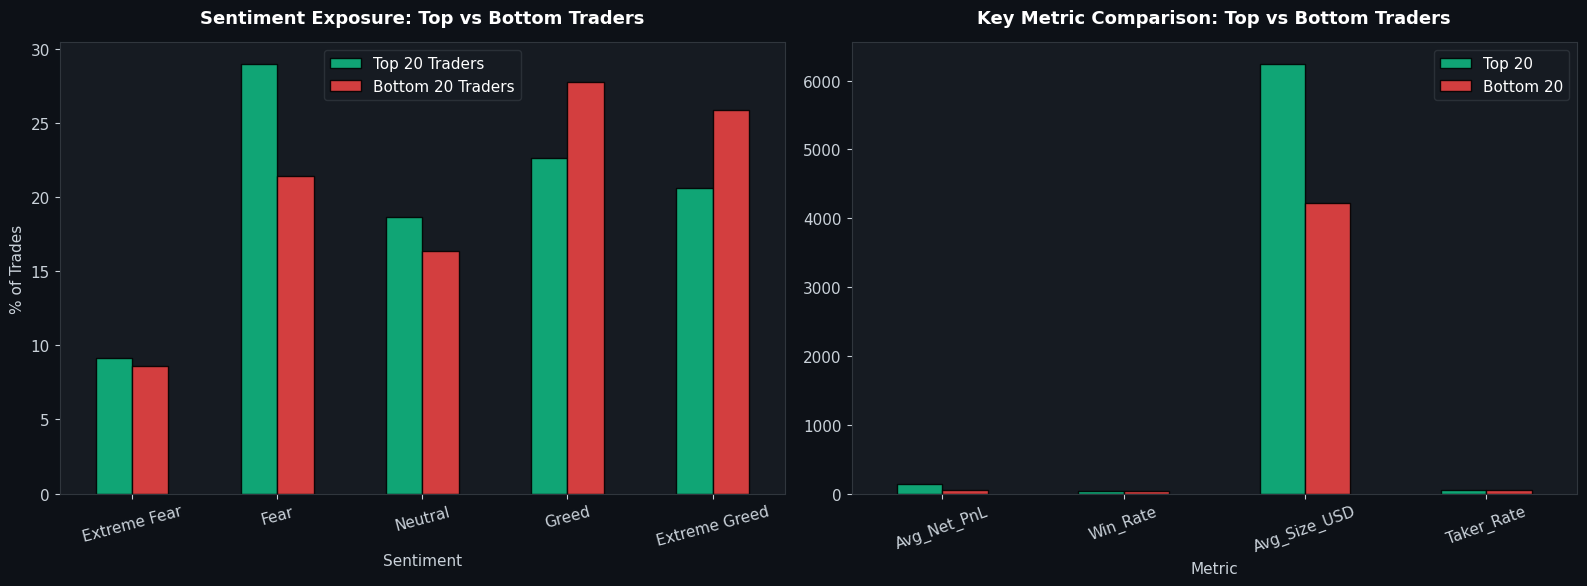

  Saved: fig10_trader_segmentation.png


In [17]:
trader_stats = (
    analysis_df.groupby('account', observed=True)
    .agg(
        Total_Net_PnL=('net_pnl','sum'),
        Avg_Net_PnL=('net_pnl','mean'),
        Trade_Count=('net_pnl','count'),
        Win_Rate=('net_pnl', lambda x: (x>0).sum()/len(x)*100),
        Avg_Size_USD=('size_usd','mean'),
        Total_Fee=('fee','sum'),
        Taker_Rate=('crossed', lambda x: x.sum()/len(x)*100),
    )
    .sort_values('Total_Net_PnL', ascending=False)
    .round(3)
)

top20    = trader_stats.head(20).index.tolist()
bottom20 = trader_stats.tail(20).index.tolist()

print('=== TOP 10 TRADERS ===')
display(trader_stats.head(10).style.background_gradient(cmap='Greens', subset=['Total_Net_PnL','Win_Rate']))

print('\n=== BOTTOM 10 TRADERS ===')
display(trader_stats.tail(10).style.background_gradient(cmap='Reds', subset=['Total_Net_PnL']))

# Sentiment exposure comparison
top_sent = analysis_df[analysis_df['account'].isin(top20)]['sentiment'].value_counts(normalize=True)*100
bot_sent = analysis_df[analysis_df['account'].isin(bottom20)]['sentiment'].value_counts(normalize=True)*100
compare  = pd.DataFrame({'Top 20 Traders': top_sent, 'Bottom 20 Traders': bot_sent}).reindex(order_present).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')

compare.plot(kind='bar', ax=ax1, color=['#10b981','#ef4444'], edgecolor='black', alpha=0.88)
ax1.set_facecolor('#161b22')
ax1.set_title('Sentiment Exposure: Top vs Bottom Traders', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('% of Trades')
ax1.tick_params(axis='x', rotation=15)
ax1.legend(facecolor='#161b22', labelcolor='white')

# Compare key metrics
metrics = ['Avg_Net_PnL','Win_Rate','Avg_Size_USD','Taker_Rate']
top_means = trader_stats.loc[top20, metrics].mean()
bot_means = trader_stats.loc[bottom20, metrics].mean()
compare_metrics = pd.DataFrame({'Top 20': top_means, 'Bottom 20': bot_means})

compare_metrics.plot(kind='bar', ax=ax2, color=['#10b981','#ef4444'], edgecolor='black', alpha=0.88)
ax2.set_facecolor('#161b22')
ax2.set_title('Key Metric Comparison: Top vs Bottom Traders', color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Metric')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(facecolor='#161b22', labelcolor='white')

plt.tight_layout()
save('fig10_trader_segmentation.png')


## 🧪 Step 13: Statistical Significance Tests
> **NEW:** Kruskal-Wallis test to check if net PnL differences across sentiment groups are statistically significant (non-parametric — appropriate for skewed trading PnL data).

In [18]:
groups = [
    analysis_df[analysis_df['sentiment']==s]['net_pnl'].dropna().values
    for s in order_present if s in analysis_df['sentiment'].unique()
]

stat, p_kruskal = kruskal(*groups)
print('=== KRUSKAL-WALLIS TEST: Net PnL across Sentiment Groups ===')
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p_kruskal:.6f}')
if p_kruskal < 0.05:
    print('  Result: SIGNIFICANT — PnL distributions differ meaningfully across sentiment regimes (p < 0.05)')
else:
    print('  Result: NOT significant — no statistically meaningful PnL difference across sentiments')

# Pairwise Mann-Whitney U between adjacent sentiment classes
print('\n=== PAIRWISE MANN-WHITNEY U TESTS ===')
present = [s for s in order_present if s in analysis_df['sentiment'].unique()]
rows = []
for i in range(len(present)-1):
    g1 = analysis_df[analysis_df['sentiment']==present[i]]['net_pnl'].dropna()
    g2 = analysis_df[analysis_df['sentiment']==present[i+1]]['net_pnl'].dropna()
    u, p = mannwhitneyu(g1, g2, alternative='two-sided')
    rows.append({'Comparison': f'{present[i]} vs {present[i+1]}',
                 'U-stat': round(u,2), 'p-value': round(p,6),
                 'Significant': 'YES' if p < 0.05 else 'NO'})
display(pd.DataFrame(rows))


=== KRUSKAL-WALLIS TEST: Net PnL across Sentiment Groups ===
  H-statistic : 1176.7916
  p-value     : 0.000000
  Result: SIGNIFICANT — PnL distributions differ meaningfully across sentiment regimes (p < 0.05)

=== PAIRWISE MANN-WHITNEY U TESTS ===


,Comparison,U-stat,p-value,Significant
0,Extreme Fear vs Fear,6.380210e+08,0.000000,YES
1,Fear vs Neutral,1.180867e+09,0.000364,YES
2,Neutral vs Greed,9.762416e+08,0.000000,YES
3,Greed vs Extreme Greed,8.825675e+08,0.000000,YES


## 🔗 Step 14: Correlation Analysis
> **FIX #4:** Proper magnitude interpretation of Pearson r — not blindly calling a near-zero correlation 'influential'.

Pearson r (Net PnL vs F&G Index) : 0.0083
p-value                          : 0.000131
Interpretation : negligible (no meaningful linear relationship) positive correlation


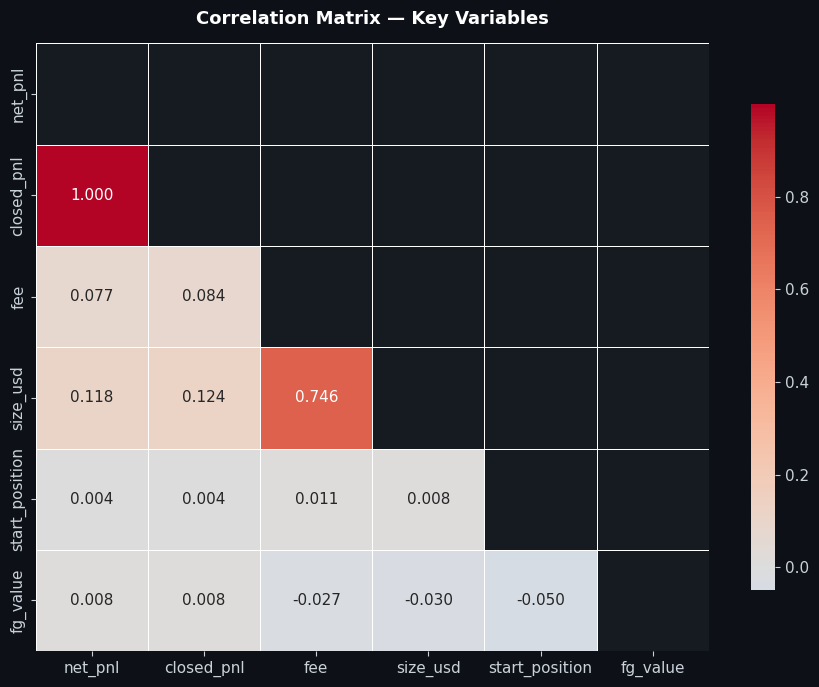

  Saved: fig11_correlation_matrix.png


In [19]:
num_cols = ['net_pnl','closed_pnl','fee','size_usd','start_position','fg_value']
num_cols = [c for c in num_cols if c in analysis_df.columns]
corr_df  = analysis_df[num_cols].dropna()

r, p = stats.pearsonr(corr_df['net_pnl'], corr_df['fg_value'])

def interpret_r(r):
    a = abs(r)
    if a < 0.1:   return 'negligible (no meaningful linear relationship)'
    elif a < 0.3: return 'weak'
    elif a < 0.5: return 'moderate'
    elif a < 0.7: return 'strong'
    else:         return 'very strong'

direction = 'positive' if r > 0 else 'negative'
print(f'Pearson r (Net PnL vs F&G Index) : {r:.4f}')
print(f'p-value                          : {p:.6f}')
print(f'Interpretation : {interpret_r(r)} {direction} correlation')
if p >= 0.05:
    print('Note: Not statistically significant — do not infer causation.')

# Full correlation heatmap
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7), facecolor='#0d1117')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, mask=mask,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11})
ax.set_title('Correlation Matrix — Key Variables', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
save('fig11_correlation_matrix.png')


## 📅 Step 15: Time-Series Analysis

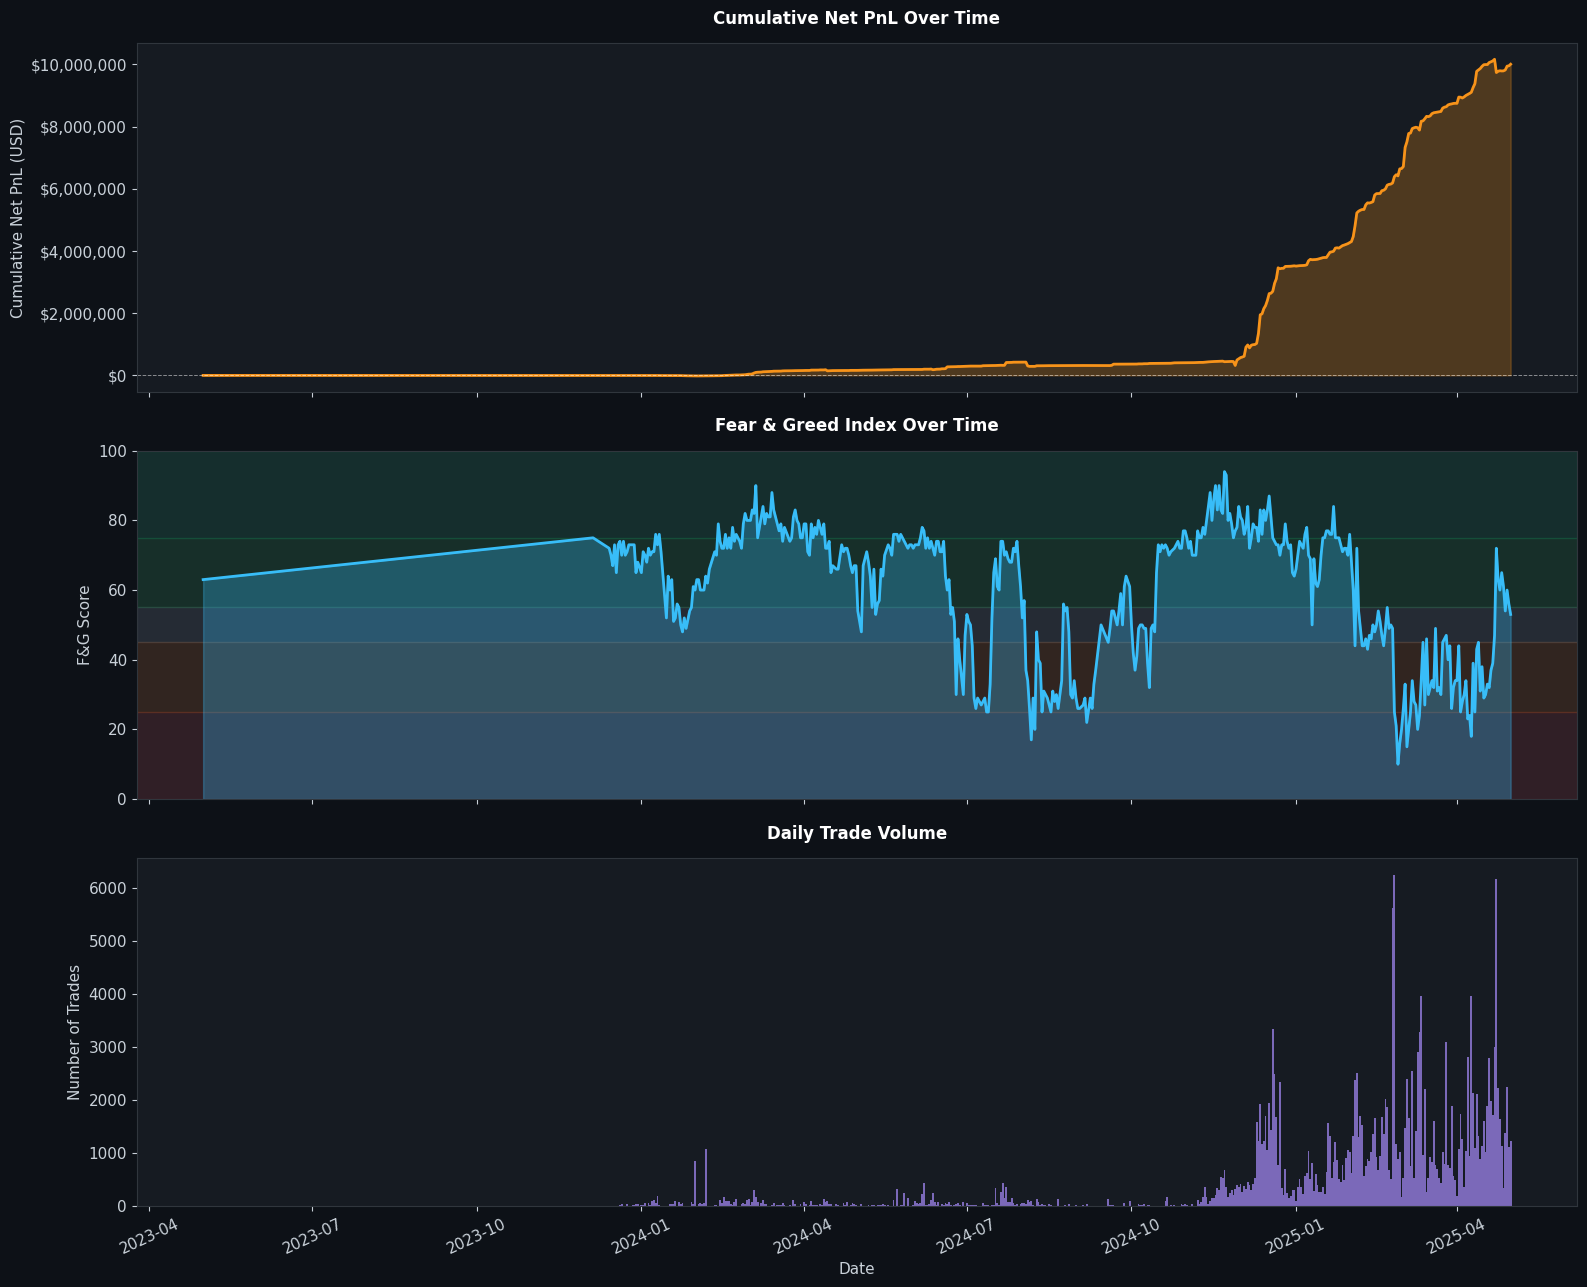

  Saved: fig12_timeseries.png


In [20]:
daily = (
    analysis_df.groupby('date_only')
    .agg(
        total_net_pnl=('net_pnl','sum'),
        trade_count=('net_pnl','count'),
        fg_value=('fg_value','mean'),
        win_rate=('net_pnl', lambda x: (x>0).sum()/len(x)*100),
        avg_size=('size_usd','mean'),
    ).reset_index()
)
daily['cumulative_net_pnl'] = daily['total_net_pnl'].cumsum()

fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#0d1117', sharex=True)

# Panel 1: Cumulative net PnL
axes[0].set_facecolor('#161b22')
axes[0].fill_between(daily['date_only'], daily['cumulative_net_pnl'], alpha=0.25, color='#f7931a')
axes[0].plot(daily['date_only'], daily['cumulative_net_pnl'], color='#f7931a', lw=2)
axes[0].axhline(0, color='white', lw=0.7, ls='--', alpha=0.5)
axes[0].set_title('Cumulative Net PnL Over Time', color='white', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cumulative Net PnL (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Panel 2: Fear & Greed index with colored bands
axes[1].set_facecolor('#161b22')
axes[1].axhspan(0,  25, alpha=0.12, color='#ef4444')
axes[1].axhspan(25, 45, alpha=0.12, color='#f97316')
axes[1].axhspan(45, 55, alpha=0.12, color='#94a3b8')
axes[1].axhspan(55, 75, alpha=0.12, color='#22c55e')
axes[1].axhspan(75,100, alpha=0.12, color='#10b981')
axes[1].fill_between(daily['date_only'], daily['fg_value'], alpha=0.3, color='#38bdf8')
axes[1].plot(daily['date_only'], daily['fg_value'], color='#38bdf8', lw=2)
axes[1].set_ylim(0, 100)
axes[1].set_title('Fear & Greed Index Over Time', color='white', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F&G Score')

# Panel 3: Daily trade count
axes[2].set_facecolor('#161b22')
axes[2].bar(daily['date_only'], daily['trade_count'], color='#a78bfa', alpha=0.7, width=1)
axes[2].set_title('Daily Trade Volume', color='white', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Trades')
axes[2].set_xlabel('Date')

plt.xticks(rotation=25)
plt.tight_layout()
save('fig12_timeseries.png')


## 💡 Step 16: Dynamic Insights & Strategy Recommendations
> **FIX #5:** All insight text is now 100% data-driven — computed from actual results, never hardcoded.

In [21]:
print('=' * 65)
print('   DATA-DRIVEN INSIGHTS: TRADER BEHAVIOR & MARKET SENTIMENT')
print('=' * 65)

# Insight 1: Best sentiment for avg net PnL
best_sent_pnl = summary['Avg_Net_PnL'].idxmax()
best_pnl_val  = summary['Avg_Net_PnL'].max()
worst_sent    = summary['Avg_Net_PnL'].idxmin()
worst_pnl_val = summary['Avg_Net_PnL'].min()
print(f'\n1. BEST SENTIMENT FOR PROFITABILITY')
print(f'   Highest avg net PnL = ${best_pnl_val:.2f} during "{best_sent_pnl}"')
print(f'   Worst avg net PnL   = ${worst_pnl_val:.2f} during "{worst_sent}"')

# Insight 2: Win rate
best_wr_sent = summary['Win_Rate_%'].idxmax()
best_wr_val  = summary['Win_Rate_%'].max()
print(f'\n2. HIGHEST WIN RATE')
print(f'   {best_wr_val:.1f}% win rate during "{best_wr_sent}"')
if best_wr_val > 50:
    print(f'   -> Traders beat the coin-flip during {best_wr_sent}')
else:
    print(f'   -> Win rate never exceeds 50% — edge is in sizing, not frequency')

# Insight 3: Correlation
print(f'\n3. SENTIMENT-PNL CORRELATION')
print(f'   Pearson r = {r:.4f}  ({interpret_r(r)} {direction} correlation)')
if abs(r) < 0.1:
    print('   -> F&G Index alone is NOT a reliable predictor of individual trade PnL.')
    print('      Use it as a regime filter, not a signal.')
elif r > 0:
    print('   -> Greedier markets tend to produce better trade outcomes.')
else:
    print('   -> Fearful markets tend to produce better trade outcomes (contrarian signal).')

# Insight 4: Statistical significance
print(f'\n4. STATISTICAL SIGNIFICANCE (Kruskal-Wallis)')
print(f'   p = {p_kruskal:.6f}  ->  {"SIGNIFICANT" if p_kruskal < 0.05 else "NOT SIGNIFICANT"}')
if p_kruskal < 0.05:
    print('   -> PnL distributions ARE statistically different across sentiment regimes.')
    print('      Sentiment is a meaningful regime classifier for trading strategy.')
else:
    print('   -> PnL differences across sentiment groups may be due to chance.')

# Insight 5: Fee impact
total_fee  = analysis_df['fee'].sum()
total_gpnl = analysis_df['closed_pnl'].sum()
total_npnl = analysis_df['net_pnl'].sum()
fee_drag   = (total_fee / abs(total_gpnl) * 100) if total_gpnl != 0 else 0
print(f'\n5. FEE IMPACT ON PROFITABILITY')
print(f'   Total Gross PnL : ${total_gpnl:,.2f}')
print(f'   Total Fees Paid : ${total_fee:,.2f}  ({fee_drag:.1f}% of gross PnL)')
print(f'   Total Net PnL   : ${total_npnl:,.2f}')
if fee_drag > 20:
    print('   -> HIGH fee drag. Strategies must account for transaction costs.')
else:
    print('   -> Fee drag is manageable relative to gross PnL.')

# Insight 6: Direction
best_dir = dir_summary.loc[dir_summary['Avg_Net_PnL'].idxmax()]
print(f'\n6. BEST DIRECTION × SENTIMENT COMBINATION')
print(f'   {best_dir["side"]} trades during "{best_dir["sentiment"]}" had highest avg net PnL: ${best_dir["Avg_Net_PnL"]:.2f}')

print(f'\n7. STRATEGY RECOMMENDATIONS')
print(f'   -> Prioritize {best_dir["side"]} positions during {best_dir["sentiment"]} market conditions')
print(f'   -> Target coins with consistently positive PnL across sentiment regimes')
print(f'   -> Use sentiment as a regime filter to adjust position sizing, not just direction')
print(f'   -> Monitor taker rate — high taker % in Extreme Greed signals FOMO-driven entries')
print(f'   -> Always calculate net PnL (after fees) — gross figures can be misleading')

print('\n' + '=' * 65)


   DATA-DRIVEN INSIGHTS: TRADER BEHAVIOR & MARKET SENTIMENT

1. BEST SENTIMENT FOR PROFITABILITY
   Highest avg net PnL = $67.22 during "Extreme Greed"
   Worst avg net PnL   = $33.26 during "Neutral"

2. HIGHEST WIN RATE
   46.8% win rate during "Extreme Greed"
   -> Win rate never exceeds 50% — edge is in sizing, not frequency

3. SENTIMENT-PNL CORRELATION
   Pearson r = 0.0083  (negligible (no meaningful linear relationship) positive correlation)
   -> F&G Index alone is NOT a reliable predictor of individual trade PnL.
      Use it as a regime filter, not a signal.

4. STATISTICAL SIGNIFICANCE (Kruskal-Wallis)
   p = 0.000000  ->  SIGNIFICANT
   -> PnL distributions ARE statistically different across sentiment regimes.
      Sentiment is a meaningful regime classifier for trading strategy.

5. FEE IMPACT ON PROFITABILITY
   Total Gross PnL : $10,254,486.95
   Total Fees Paid : $245,849.21  (2.4% of gross PnL)
   Total Net PnL   : $10,008,637.74
   -> Fee drag is manageable relative

## 📤 Step 17: Export All Results

In [22]:
# Save CSVs
analysis_df.to_csv('merged_analysis_dataset.csv', index=False)
summary.to_csv('sentiment_pnl_summary.csv')
coin_summary.to_csv('coin_summary.csv')
trader_stats.to_csv('trader_stats.csv')
dir_summary.to_csv('direction_sentiment_summary.csv', index=False)
daily.to_csv('daily_timeseries.csv', index=False)

# Save interactive Plotly charts as HTML (viewable when shared)
fig_px = px.box(
    analysis_df, x='sentiment', y='net_pnl',
    category_orders={'sentiment': SENTIMENT_ORDER},
    color='sentiment', color_discrete_map=PALETTE,
    title='Interactive: Net PnL Distribution by Sentiment',
    template='plotly_dark'
)
fig_px.update_layout(showlegend=False)
fig_px.write_html('interactive_pnl_boxplot.html')

fig_ts = make_subplots(rows=2, cols=1, shared_xaxes=True,
                       subplot_titles=['Cumulative Net PnL','Fear & Greed Index'])
fig_ts.add_trace(go.Scatter(x=daily['date_only'], y=daily['cumulative_net_pnl'],
                            fill='tozeroy', name='Cum Net PnL', line_color='#f7931a'), row=1, col=1)
fig_ts.add_trace(go.Scatter(x=daily['date_only'], y=daily['fg_value'],
                            fill='tozeroy', name='F&G Index', line_color='#38bdf8'), row=2, col=1)
fig_ts.update_layout(template='plotly_dark', title='Interactive: Time-Series Analysis', height=600)
fig_ts.write_html('interactive_timeseries.html')

print('CSV exports done.')
print('Plotly HTML exports done.')

# Bundle everything into ZIP
all_outputs = (
    SAVED_FIGS +
    ['merged_analysis_dataset.csv','sentiment_pnl_summary.csv',
     'coin_summary.csv','trader_stats.csv',
     'direction_sentiment_summary.csv','daily_timeseries.csv',
     'interactive_pnl_boxplot.html','interactive_timeseries.html']
)

with zipfile.ZipFile('PrimeTrade_Analysis_v2.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for f in all_outputs:
        if os.path.exists(f):
            z.write(f)
            print(f'  Added: {f}')
        else:
            print(f'  SKIPPED (not found): {f}')

files.download('PrimeTrade_Analysis_v2.zip')
print(f'\nDone! {len(all_outputs)} files packaged.')


CSV exports done.
Plotly HTML exports done.
  Added: fig1_sentiment_distribution.png
  Added: fig2_pnl_winrate_by_sentiment.png
  Added: fig3_boxplot_net_pnl.png
  Added: fig4_outcome_heatmap.png
  Added: fig5_buy_sell_by_sentiment.png
  Added: fig6_coin_breakdown.png
  Added: fig7_coin_sentiment_heatmap.png
  Added: fig8_maker_taker_sentiment.png
  Added: fig9_position_sizing.png
  Added: fig9_position_sizing.png
  Added: fig10_trader_segmentation.png
  Added: fig11_correlation_matrix.png
  Added: fig12_timeseries.png
  Added: merged_analysis_dataset.csv
  Added: sentiment_pnl_summary.csv
  Added: coin_summary.csv
  Added: trader_stats.csv
  Added: direction_sentiment_summary.csv
  Added: daily_timeseries.csv
  Added: interactive_pnl_boxplot.html
  Added: interactive_timeseries.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! 21 files packaged.
